In [1]:
import sklearn
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

RANDOM_SEED = 42

plt.style.use('seaborn-v0_8') # pretty matplotlib plots

import seaborn as sns
sns.set_theme('notebook', style='whitegrid', font_scale=1.25)

In [2]:
x_train_df = pd.read_csv(os.path.join('data', 'x_train.csv'))
y_train_df = pd.read_csv(os.path.join('data', 'y_train.csv'))
x_test_df = pd.read_csv(os.path.join('data', 'x_test.csv'))

In [3]:
cols = [
    'avg_word_length',              # or info_characters_per_word, pick one
    'avg_sentence_length',          # or info_words_per_sentence, pick one
    'type_token_ratio',             # or info_type_token_ratio, pick one
    'pronoun_freq',
    'punctuation_frequency',
    'sentiment_polarity',
    'sentiment_subjectivity',
    'info_syll_per_word',
    'readability_Kincaid',
    'readability_ARI',
    'readability_Coleman-Liau',
    'readability_FleschReadingEase',
    'readability_GunningFogIndex',
    'readability_LIX',
    'readability_SMOGIndex',
    'readability_RIX',
    'readability_DaleChallIndex',
]

In [4]:
# load embeddings
train_embeddings = np.load('data/x_train_BERT_embeddings.npz')['arr_0']
test_embeddings = np.load('data/x_test_BERT_embeddings.npz')['arr_0']

print(train_embeddings.shape)  # should be (n_train_samples, 768)
train_embeds_df = pd.DataFrame(train_embeddings)
test_embeds_df = pd.DataFrame(test_embeddings)

# combine BERT embeddings with your numeric features
x_train_combined = np.hstack([
    train_embeddings,
    x_train_df[cols].values  # your handcrafted cols
])
x_test_combined = np.hstack([
    test_embeddings,
    x_test_df[cols].values
])

(5557, 768)


In [5]:
def make_random_forest_pipeline(max_depth=5, min_samples_leaf=2, n_estimators=200):
    steps = [
        ('rescaler', sklearn.preprocessing.MinMaxScaler()),
        ("clf", RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            class_weight="balanced",
            random_state=RANDOM_SEED,
            n_jobs=-1,
        )),
    ]
    pipeline = sklearn.pipeline.Pipeline(steps=steps)
    return pipeline

In [20]:
def make_logit_pipeline(C=1.0, l1_ratio=0, class_weight=None):
    steps = [
        ('min_max_scaler',sklearn.preprocessing.MinMaxScaler()),
        ('logit', sklearn.linear_model.LogisticRegression(
            solver="lbfgs", 
            l1_ratio=l1_ratio, 
            C=C, 
            max_iter=1000, 
            class_weight=class_weight, 
            random_state=RANDOM_SEED)
        )
    ]
    pipeline = sklearn.pipeline.Pipeline(steps=steps)
    return pipeline

In [7]:
groups = x_train_df['author']
y_target_df = y_train_df['Coarse Label']

kf = sklearn.model_selection.StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)

logit_pl = make_logit_pipeline()
aucs = []
for train_index, val_index in kf.split(x_train_combined, y_target_df, groups=groups):
    x_train_fold = x_train_combined[train_index]  # numpy indexing now
    y_train_fold = y_target_df.iloc[train_index]
    x_val_fold = x_train_combined[val_index]
    y_val_fold = y_target_df.iloc[val_index]

    logit_pl.fit(x_train_fold, y_train_fold)
    y_pred_proba = logit_pl.predict_proba(x_val_fold)[:, 1]

    auc = sklearn.metrics.roc_auc_score(y_val_fold, y_pred_proba)
    aucs.append(auc)

mean_auc = np.mean(aucs)
print(f"AUC for BERT embeds + Cols for Logistic Regression: {mean_auc:.4f}")

logit_pl.fit(x_train_combined, y_target_df)
y_test_pred_proba = logit_pl.predict_proba(x_test_combined)[:, 1]
with open("yproba1_test_p2_BERT+cols_logit.txt", "w") as f:
    for pred in y_test_pred_proba:
        f.write(f"{pred}\n")

AUC for BERT embeds + Cols for Logistic Regression: 0.7404


AUC of: 0.7660123732765706 for C of: 0.0001
AUC of: 0.7675055570024334 for C of: 0.00031622776601683794
AUC of: 0.7695349193788662 for C of: 0.001
AUC of: 0.7710945674868495 for C of: 0.0031622776601683794
AUC of: 0.772513005669263 for C of: 0.01
AUC of: 0.770858905283994 for C of: 0.03162277660168379
AUC of: 0.7649706811171859 for C of: 0.1
AUC of: 0.7539104606534497 for C of: 0.31622776601683794
AUC of: 0.7403865350540835 for C of: 1.0
AUC of: 0.7272758417301012 for C of: 3.1622776601683795
AUC of: 0.7175947854056726 for C of: 10.0
AUC of: 0.7123856764719413 for C of: 31.622776601683793
AUC of: 0.7108018456152182 for C of: 100.0
AUC of: 0.7094230035891489 for C of: 316.22776601683796
AUC of: 0.708905674580992 for C of: 1000.0
AUC of: 0.7088425682820633 for C of: 3162.2776601683795
AUC of: 0.708772733879721 for C of: 10000.0
Best C: 0.01, Best AUC: 0.772513005669263


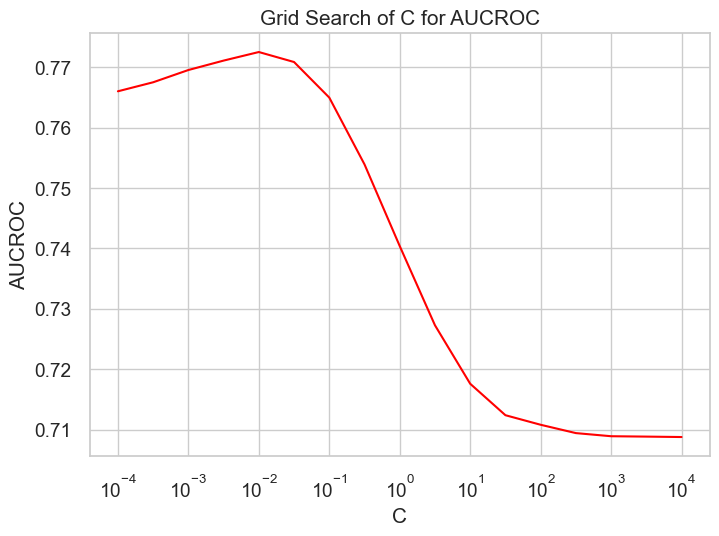

In [8]:
C_grid = np.logspace(-4, 4, 17)
hypers_list = []

for C in C_grid:
  pl = make_logit_pipeline(C=C)
  aucs = []
  for train_index, val_index in kf.split(x_train_combined, y_target_df, groups=groups):
    x_train_fold = x_train_combined[train_index]
    y_train_fold = y_target_df.iloc[train_index]
    x_val_fold = x_train_combined[val_index]
    y_val_fold = y_target_df.iloc[val_index]

    pl.fit(x_train_fold, y_train_fold)
    y_pred_proba = pl.predict_proba(x_val_fold)[:, 1]

    auc = sklearn.metrics.roc_auc_score(y_val_fold, y_pred_proba)
    aucs.append(auc)
  mean_auc = np.mean(aucs)
  hypers_list.append((C, mean_auc))

AUC_vals = [h[1] for h in hypers_list]
for C, AUC in zip(C_grid, AUC_vals):
    print(f"AUC of: {AUC} for C of: {C}")
plt.plot(C_grid, AUC_vals, color='red')
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('AUCROC')
plt.title('Grid Search of C for AUCROC')

best_C, best_auc = max(hypers_list, key=lambda x: x[1])
print(f"Best C: {best_C}, Best AUC: {best_auc}")

In [9]:
logit_pl = make_logit_pipeline(C=best_C)
logit_pl.fit(x_train_combined, y_target_df)
y_test_pred_proba = logit_pl.predict_proba(x_test_combined)[:, 1]
with open("yproba1_test_p2_BERT+cols_logit_bestC.txt", "w") as f:
    for pred in y_test_pred_proba:
        f.write(f"{pred}\n")

In [10]:
logit_pl = make_logit_pipeline()
aucs = []
for train_index, val_index in kf.split(train_embeds_df, y_target_df, groups=groups):
    x_train_fold = train_embeds_df.iloc[train_index]  # numpy indexing now
    y_train_fold = y_target_df.iloc[train_index]
    x_val_fold = train_embeds_df.iloc[val_index]
    y_val_fold = y_target_df.iloc[val_index]

    logit_pl.fit(x_train_fold, y_train_fold)
    y_pred_proba = logit_pl.predict_proba(x_val_fold)[:, 1]

    auc = sklearn.metrics.roc_auc_score(y_val_fold, y_pred_proba)
    aucs.append(auc)

mean_auc = np.mean(aucs)
print(f"AUC for BERT embeds for Logistic Regression: {mean_auc:.4f}")

logit_pl.fit(train_embeds_df, y_target_df)
y_test_pred_proba = logit_pl.predict_proba(test_embeds_df)[:, 1]
with open("yproba1_test_p2_BERT_logit.txt", "w") as f:
    for pred in y_test_pred_proba:
        f.write(f"{pred}\n")

AUC for BERT embeds for Logistic Regression: 0.7415


AUC of: 0.7654881810763008 for C of: 0.0001
AUC of: 0.7670344579457401 for C of: 0.00031622776601683794
AUC of: 0.7691817778523893 for C of: 0.001
AUC of: 0.7708223408153791 for C of: 0.0031622776601683794
AUC of: 0.7721798729036727 for C of: 0.01
AUC of: 0.7706464409669548 for C of: 0.03162277660168379
AUC of: 0.7650151382344117 for C of: 0.1
AUC of: 0.7546899853253167 for C of: 0.31622776601683794
AUC of: 0.7414683453071844 for C of: 1.0
AUC of: 0.7286351992293898 for C of: 3.1622776601683795
AUC of: 0.7189259953598245 for C of: 10.0
AUC of: 0.7136801087358535 for C of: 31.622776601683793
AUC of: 0.7114161912260464 for C of: 100.0
AUC of: 0.7111327603747144 for C of: 316.22776601683796
AUC of: 0.7111114711848309 for C of: 1000.0
AUC of: 0.7110991274076304 for C of: 3162.2776601683795
AUC of: 0.7107374019518744 for C of: 10000.0
Best C: 0.01, Best AUC: 0.7721798729036727


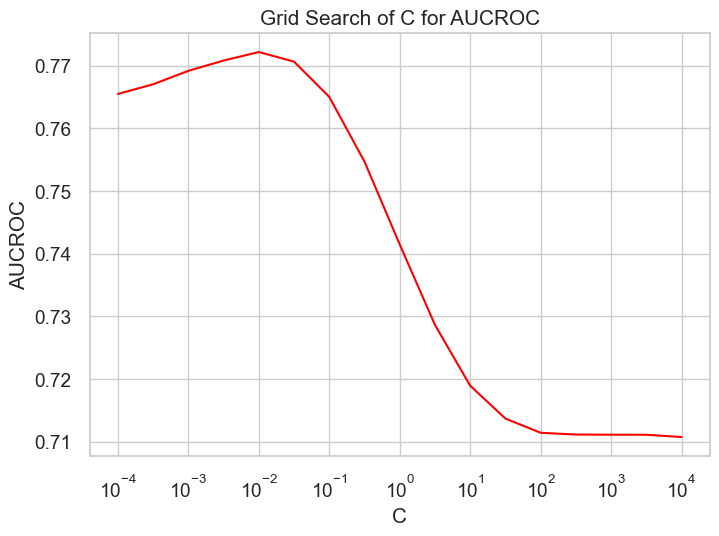

In [11]:
hypers_list = []

for C in C_grid:
  pl = make_logit_pipeline(C=C)
  aucs = []
  for train_index, val_index in kf.split(train_embeds_df, y_target_df, groups=groups):
    x_train_fold = train_embeds_df.iloc[train_index]
    y_train_fold = y_target_df.iloc[train_index]
    x_val_fold = train_embeds_df.iloc[val_index]
    y_val_fold = y_target_df.iloc[val_index]

    pl.fit(x_train_fold, y_train_fold)
    y_pred_proba = pl.predict_proba(x_val_fold)[:, 1]

    auc = sklearn.metrics.roc_auc_score(y_val_fold, y_pred_proba)
    aucs.append(auc)
  mean_auc = np.mean(aucs)
  hypers_list.append((C, mean_auc))

AUC_vals = [h[1] for h in hypers_list]
for C, AUC in zip(C_grid, AUC_vals):
    print(f"AUC of: {AUC} for C of: {C}")
plt.plot(C_grid, AUC_vals, color='red')
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('AUCROC')
plt.title('Grid Search of C for AUCROC')

best_C, best_auc = max(hypers_list, key=lambda x: x[1])
print(f"Best C: {best_C}, Best AUC: {best_auc}")

In [12]:
logit_pl = make_logit_pipeline(C=best_C)
logit_pl.fit(train_embeds_df, y_target_df)
y_test_pred_proba = logit_pl.predict_proba(test_embeds_df)[:, 1]
with open("yproba1_test_p2_BERT_logit_bestC.txt", "w") as f:
    for pred in y_test_pred_proba:
        f.write(f"{pred}\n")

In [13]:
from sklearn.preprocessing import PolynomialFeatures

In [14]:
# def make_logit_pipeline_poly(degree=1, C=1.0):
#     steps = [
#         ('poly_features', PolynomialFeatures(degree=degree, include_bias=False)),
#         ('rescaler', sklearn.preprocessing.MinMaxScaler()),
#         ('logit', sklearn.linear_model.LogisticRegression(solver="lbfgs", l1_ratio=0, C=C, max_iter=1000))
#     ]
#     pipeline = sklearn.pipeline.Pipeline(steps=steps)
#     return pipeline

In [15]:
# degrees = [1, 2, 3, 4, 5, 6, 7]
# hypers_list = []

# for d in degrees:
#     for C in C_grid:
#         pl = make_logit_pipeline_poly(degree=d, C=C)
#         aucs = []
#         for train_index, val_index in kf.split(train_embeds_df, y_target_df, groups=groups):
#             x_train_fold = train_embeds_df.iloc[train_index]
#             y_train_fold = y_target_df.iloc[train_index]
#             x_val_fold = train_embeds_df.iloc[val_index]
#             y_val_fold = y_target_df.iloc[val_index]
            
#             pl.fit(x_train_fold, y_train_fold)
#             y_pred_proba = pl.predict_proba(x_val_fold)[:, 1]
        
#             auc = sklearn.metrics.roc_auc_score(y_val_fold, y_pred_proba)
#             aucs.append(auc)
#         mean_auc = np.mean(aucs)
#         hypers_list.append((d, C, mean_auc))

# AUC_vals = [h[2] for h in hypers_list]
# for d, C, AUC in zip(degrees, C_grid, AUC_vals):
#     print(f"AUC of: {AUC} for C of: {C}")

# # plt.plot(C_grid, AUC_vals, color='red')
# # plt.xscale('log')
# # plt.xlabel('C')
# # plt.ylabel('AUCROC')
# # plt.title('Grid Search of C for AUCROC')

# best_d, best_C, best_auc = max(hypers_list, key=lambda x: x[2])
# print(f"Best d: {best_d}, Best C: {best_C}, Best AUC: {best_auc}")

In [16]:
print(y_target_df.value_counts(normalize=True))

Coarse Label
Key Stage 4-5    0.548497
Key Stage 2-3    0.451503
Name: proportion, dtype: float64


In [17]:
logit_pl = make_logit_pipeline(class_weight='balanced')
aucs = []
for train_index, val_index in kf.split(x_train_combined, y_target_df, groups=groups):
    x_train_fold = x_train_combined[train_index]  # numpy indexing now
    y_train_fold = y_target_df.iloc[train_index]
    x_val_fold = x_train_combined[val_index]
    y_val_fold = y_target_df.iloc[val_index]

    logit_pl.fit(x_train_fold, y_train_fold)
    y_pred_proba = logit_pl.predict_proba(x_val_fold)[:, 1]

    auc = sklearn.metrics.roc_auc_score(y_val_fold, y_pred_proba)
    aucs.append(auc)

mean_auc = np.mean(aucs)
print(f"AUC for BERT embeds + Cols for Logistic Regression: {mean_auc:.4f}")

logit_pl.fit(x_train_combined, y_target_df)
y_test_pred_proba = logit_pl.predict_proba(x_test_combined)[:, 1]
with open("yproba1_test_p2_BERT+cols_logit_balanced.txt", "w") as f:
    for pred in y_test_pred_proba:
        f.write(f"{pred}\n")

AUC for BERT embeds + Cols for Logistic Regression: 0.7407


AUC of: 0.7660545447532531 for C of: 0.0001
AUC of: 0.7674698709791132 for C of: 0.00031622776601683794
AUC of: 0.7695145148043187 for C of: 0.001
AUC of: 0.771203819636737 for C of: 0.0031622776601683794
AUC of: 0.7724411954753101 for C of: 0.01
AUC of: 0.7708858666490231 for C of: 0.03162277660168379
AUC of: 0.7649649255624065 for C of: 0.1
AUC of: 0.7540915144662869 for C of: 0.31622776601683794
AUC of: 0.7407192759796105 for C of: 1.0
AUC of: 0.7276666059503307 for C of: 3.1622776601683795
AUC of: 0.7182175272459247 for C of: 10.0
AUC of: 0.7123081340246525 for C of: 31.622776601683793
AUC of: 0.7107097170851391 for C of: 100.0
AUC of: 0.709461760020719 for C of: 316.22776601683796
AUC of: 0.7096521762290374 for C of: 1000.0
AUC of: 0.7092913678265397 for C of: 3162.2776601683795
AUC of: 0.7094111726526524 for C of: 10000.0
Best C: 0.01, Best AUC: 0.7724411954753101


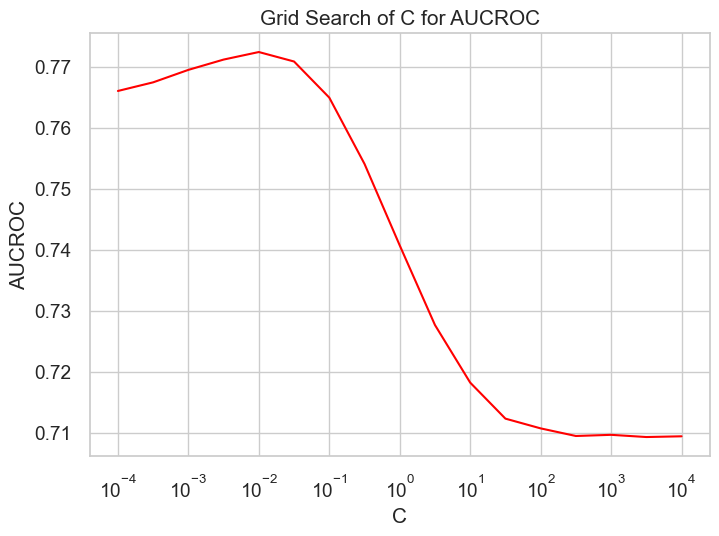

In [18]:
hypers_list = []

for C in C_grid:
  pl = make_logit_pipeline(C=C, class_weight='balanced')
  aucs = []
  for train_index, val_index in kf.split(x_train_combined, y_target_df, groups=groups):
    x_train_fold = x_train_combined[train_index]
    y_train_fold = y_target_df.iloc[train_index]
    x_val_fold = x_train_combined[val_index]
    y_val_fold = y_target_df.iloc[val_index]

    pl.fit(x_train_fold, y_train_fold)
    y_pred_proba = pl.predict_proba(x_val_fold)[:, 1]

    auc = sklearn.metrics.roc_auc_score(y_val_fold, y_pred_proba)
    aucs.append(auc)
  mean_auc = np.mean(aucs)
  hypers_list.append((C, mean_auc))

AUC_vals = [h[1] for h in hypers_list]
for C, AUC in zip(C_grid, AUC_vals):
    print(f"AUC of: {AUC} for C of: {C}")
plt.plot(C_grid, AUC_vals, color='red')
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('AUCROC')
plt.title('Grid Search of C for AUCROC')

best_C, best_auc = max(hypers_list, key=lambda x: x[1])
print(f"Best C: {best_C}, Best AUC: {best_auc}")

In [19]:
logit_pl = make_logit_pipeline(C=best_C, class_weight='balanced')
logit_pl.fit(train_embeds_df, y_target_df)
y_test_pred_proba = logit_pl.predict_proba(test_embeds_df)[:, 1]
with open("yproba1_test_p2_BERT_logit_balanced_bestC.txt", "w") as f:
    for pred in y_test_pred_proba:
        f.write(f"{pred}\n")

In [22]:
from sklearn.linear_model import SGDClassifier

In [24]:
def make_sgd_pipeline(alpha=0.0001, early_stopping=False, class_weight=None):
    steps = [
        ('min_max_scaler',sklearn.preprocessing.MinMaxScaler()),
        ('sgd', SGDClassifier(
                loss="log_loss",          # logistic regression objective
                alpha=alpha,
                class_weight=class_weight,
                early_stopping=early_stopping,
                validation_fraction=0.1,  # 10% of training fold used for validation
                n_iter_no_change=5,
                max_iter=1000,
                tol=1e-3,
                random_state=RANDOM_SEED
            )
        )
    ]
    pipeline = sklearn.pipeline.Pipeline(steps=steps)
    return pipeline

In [29]:
sgd_pl = make_sgd_pipeline()

aucs = []

for train_index, val_index in kf.split(x_train_combined, y_target_df, groups=groups):
    x_train_fold = x_train_combined[train_index]
    y_train_fold = y_target_df.iloc[train_index]

    x_val_fold = x_train_combined[val_index]
    y_val_fold = y_target_df.iloc[val_index]

    sgd_pl.fit(x_train_fold, y_train_fold)

    y_pred_proba = sgd_pl.predict_proba(x_val_fold)[:, 1]

    auc = sklearn.metrics.roc_auc_score(y_val_fold, y_pred_proba)
    aucs.append(auc)

mean_auc = np.mean(aucs)
print(f"AUC for BERT embeds + Cols for SGDClassifier: {mean_auc:.4f}")

# Train on full training data
sgd_pl.fit(x_train_combined, y_target_df)

y_test_pred_proba = sgd_pl.predict_proba(x_test_combined)[:, 1]

with open("yproba1_test_p2_BERT+cols_sgd.txt", "w") as f:
    for pred in y_test_pred_proba:
        f.write(f"{pred}\n")

AUC for BERT embeds + Cols for SGDClassifier: 0.7665


In [30]:
sgd_pl = make_sgd_pipeline(early_stopping=True)

aucs = []

for train_index, val_index in kf.split(x_train_combined, y_target_df, groups=groups):
    x_train_fold = x_train_combined[train_index]
    y_train_fold = y_target_df.iloc[train_index]

    x_val_fold = x_train_combined[val_index]
    y_val_fold = y_target_df.iloc[val_index]

    sgd_pl.fit(x_train_fold, y_train_fold)

    y_pred_proba = sgd_pl.predict_proba(x_val_fold)[:, 1]

    auc = sklearn.metrics.roc_auc_score(y_val_fold, y_pred_proba)
    aucs.append(auc)

mean_auc = np.mean(aucs)
print(f"AUC for BERT embeds + Cols for SGDClassifier: {mean_auc:.4f}")

# Train on full training data
sgd_pl.fit(x_train_combined, y_target_df)

y_test_pred_proba = sgd_pl.predict_proba(x_test_combined)[:, 1]

with open("yproba1_test_p2_BERT+cols_sgd_early_stopping.txt", "w") as f:
    for pred in y_test_pred_proba:
        f.write(f"{pred}\n")

AUC for BERT embeds + Cols for SGDClassifier: 0.7658
